In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set the style and parameters for the plots------------------------------------
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})
BLUE = '#2196F3'
RED = '#E53935'
GREEN = '#43A047'
PURPLE = '#8E24AA'
ORANGE = '#FB8C00'
PALETTE = [BLUE, RED, GREEN, PURPLE, ORANGE]

In [7]:
print('package_versions:')
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")


package_versions:
pandas: 3.0.2
numpy: 2.4.4
matplotlib: 3.10.9
seaborn: 0.13.2


In [21]:
# ── Load raw data ─────────────────────────────────────────────────────────
# Update the path if your CSV is in a different folder
df_raw = pd.read_csv('C:\\Users\\Dilip\\Desktop\\New folder\\big query\\diabetis_130.csv')
print(f" shape of the raw data: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

 shape of the raw data: 101,766 rows x 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


# Data quality audit

In [26]:
# Data quality audit
#------replace '?' with NaN-----------------------------------------

df = df_raw.replace('?', np.nan)

df.info(memory_usage=False)

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [52]:
# missing values audit

Missing= (pd.DataFrame (
    {'missing_n': df.isnull().sum(),
     'missing_pct': (df.isnull().mean() * 100).round(1)}
).query('missing_n > 0').sort_values(by='missing_pct', ascending=False))
print("Columns with missing values:")
print(Missing)


Columns with missing values:
                   missing_n  missing_pct
weight                 98569         96.9
max_glu_serum          96420         94.7
A1Cresult              84748         83.3
medical_specialty      49949         49.1
payer_code             40256         39.6
race                    2273          2.2
diag_3                  1423          1.4
diag_2                   358          0.4
diag_1                    21          0.0


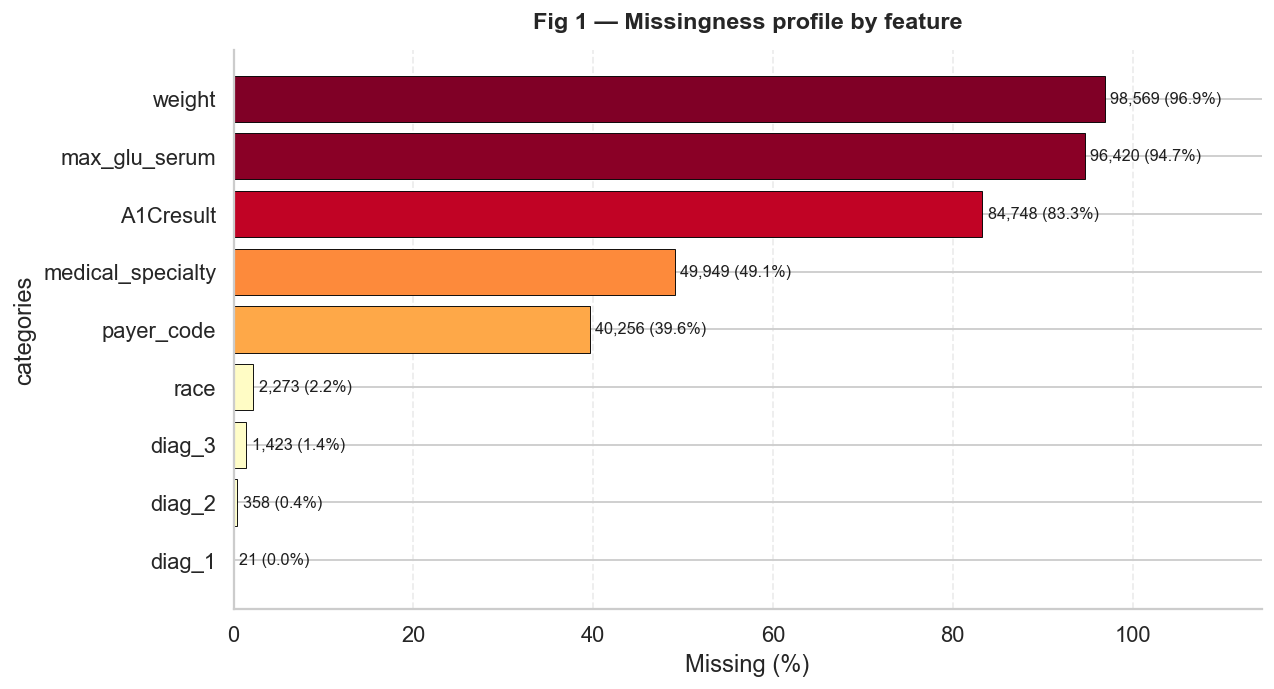


Missingness summary:
                   missing_n  missing_pct
weight                 98569         96.9
max_glu_serum          96420         94.7
A1Cresult              84748         83.3
medical_specialty      49949         49.1
payer_code             40256         39.6
race                    2273          2.2
diag_3                  1423          1.4
diag_2                   358          0.4
diag_1                    21          0.0

High-risk columns (> 20% missing):
                   missing_n  missing_pct
weight                 98569         96.9
max_glu_serum          96420         94.7
A1Cresult              84748         83.3
medical_specialty      49949         49.1
payer_code             40256         39.6


In [54]:
# ── Analytical missingness audit ─────────────────────────────────────────────
# risk band
missing['risk_level'] = pd.cut(
    missing['missing_pct'],
    bins=[-1, 1, 5, 20, 50, 100],
    labels=['Very low', 'Low', 'Moderate', 'High', 'Critical'],
    right=True
)

#  visual
fig, ax = plt.subplots(figsize=(10, 5.5))
cmap = plt.cm.get_cmap('YlOrRd')
colors = [cmap(v / max(missing['missing_pct'].max(), 1)) for v in missing['missing_pct']]

bars = ax.barh(missing.index, missing['missing_pct'],
               color=colors, edgecolor='black', linewidth=0.5)

ax.invert_yaxis()
ax.set_title('Fig 1 — Missingness profile by feature', pad=12)
ax.set_xlabel('Missing (%)')
ax.set_ylabel('categories')
ax.set_xlim(0, max(10, missing['missing_pct'].max() * 1.18))
ax.grid(axis='x', linestyle='--', alpha=0.35)

# Annotate each bar with count and percentage
for bar, count, pct in zip(bars, missing['missing_n'], missing['missing_pct']):
    ax.text(
        pct + 0.6, bar.get_y() + bar.get_height() / 2,
        f'{count:,} ({pct:.1f}%)',
        va='center', ha='left', fontsize=9, color='#1f1f1f'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_01_missing_values.png', dpi=180, bbox_inches='tight')
plt.show()

print("\nMissingness summary:")
print(Missing_values)

# Quick analytical insight
print("\nHigh-risk columns (> 20% missing):")
print(Missing_values[Missing_values['missing_pct'] > 20])


In [55]:
# ── Cardinality of categorical columns ────────────────────────────────────
cat_cols = df.select_dtypes('object').columns.tolist()
card = (df[cat_cols].nunique()
                    .sort_values(ascending=False)
                    .rename('unique_values'))
print('Categorical column cardinality:')
print(card.to_string())

Categorical column cardinality:
diag_3                      789
diag_2                      748
diag_1                      716
medical_specialty            72
payer_code                   17
age                          10
weight                        9
race                          5
glipizide                     4
glyburide-metformin           4
insulin                       4
miglitol                      4
acarbose                      4
rosiglitazone                 4
pioglitazone                  4
glyburide                     4
chlorpropamide                4
nateglinide                   4
repaglinide                   4
metformin                     4
glimepiride                   4
readmitted                    3
gender                        3
tolazamide                    3
A1Cresult                     3
max_glu_serum                 3
glimepiride-pioglitazone      2
diabetesMed                   2
change                        2
metformin-pioglitazone        2
metformi

In [56]:
# ── Target variable baseline ──────────────────────────────────────────────
vc = df['readmitted'].value_counts()
print('Readmission counts:')
print(vc.to_string())
print(f'\n30-day readmission rate: {vc["<30"] / len(df) * 100:.1f}%')

Readmission counts:
readmitted
NO     54864
>30    35545
<30    11357

30-day readmission rate: 11.2%


# Data clean and feature engg

In [57]:
# drop columns with high missingness or low cardinality

drop_cols = ['weight', 'payer_code', 'medical_specialty',
             'max_glu_serum', 'encounter_id', 'patient_nbr']
df.drop(columns=drop_cols, inplace=True)        # --------------------------------make change in the main dataframe
print(f'Dropped {len(drop_cols)} columns → shape: {df.shape}')

Dropped 6 columns → shape: (101766, 44)


In [66]:
# ── Remove invalid gender (3 rows) ────────────────────────────────────────
df = df[df['gender'] != 'Unknown/Invalid']
print(f'After gender filter: {len(df):,} rows')

# ── Remove death / hospice discharge dispositions ─────────────────────────
hospice_ids = [11, 13, 14, 19, 20, 21]
before = len(df)
df = df[~df['discharge_disposition_id'].isin(hospice_ids)]
print(f'Removed {before - len(df):,} death/hospice rows → {len(df):,} rows')


After gender filter: 99,340 rows
Removed 0 death/hospice rows → 99,340 rows


In [68]:
# ── Deduplicate: keep first encounter per patient ─────────────────────────
# Re-attach patient_nbr from raw for deduplication
df['patient_nbr']= df_raw.loc[df.index, 'patient_nbr']                 #add it back
before = len(df)
df=df.drop_duplicates(subset='patient_nbr',keep='first')               #remove duplicate patient encounters, keep first encounter
df.drop(columns='patient_nbr', inplace=True)                           #drop the patient_nbr column after deduplication
df.reset_index(drop=True, inplace=True)                                #reset index after dropping duplicates
print(f'Removed {before - len(df):,} duplicate patient encounters')
print(f'Final clean shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Removed 29,353 duplicate patient encounters
Final clean shape: 69,987 rows × 44 columns


##### After this step, you can't track patients over time anymore. Each patient is a single row. This is done on purpose because:
   -- our predicting readmission from a single visit -- we don't want data leakage 

### Features engineered
| Feature | Description |
|---|---|
| `age_mid` | Easier to analyze|
| `readmitted_binary` |This is your target variable|
| `service_utilization` | Measures overall healthcare use|
| `n_meds_active` | Measures disease severity |
| `high_utilizer` |Identifies heavy hospital users |

In [103]:
# feature engineering
## age midpoint
age_map = {
    '[0-10)': 5,
    '[10-20)': 15,
    '[20-30)': 25,
    '[30-40)': 35,
    '[40-50)': 45,
    '[50-60)': 55,
    '[60-70)': 65,
    '[70-80)': 75,
    '[80-90)': 85,
    '[90-100)': 95
}
df['age_midpoint'] = df['age'].map(age_map) 


# 2. Binary readmission target    
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)       # 1 = readmitted within 30 days, 0 = otherwise

# 3. Service utilization
df['service_utilization'] = (df['number_outpatient'] +
                              df['number_emergency'] +
                              df['number_inpatient'])

# 4. Active medications count
med_cols = ['metformin','repaglinide','nateglinide','chlorpropamide',
            'glimepiride','acetohexamide','glipizide','glyburide',
            'tolbutamide','pioglitazone','rosiglitazone','acarbose',
            'miglitol','troglitazone','tolazamide','examide','citoglipton',
            'insulin','glyburide-metformin','glipizide-metformin',
            'glimepiride-pioglitazone','metformin-rosiglitazone',
            'metformin-pioglitazone']
avail_med_cols = [c for c in med_cols if c in df.columns]
df['n_meds_active'] = df[avail_med_cols].isin(['Up','Down','Steady']).sum(axis=1)

# 5. High utilizer flag
df['high_utilizer'] = (df['number_inpatient'] >= 3).astype(int)

print('Feature engineering complete.')
print(df[['age_midpoint','readmitted_binary','service_utilization',
          'n_meds_active','high_utilizer']].describe().round(2))


   age_midpoint  readmitted_binary
0             5                  0
1            15                  0
2            25                  0
Feature engineering complete.
       age_midpoint  readmitted_binary  service_utilization  n_meds_active  \
count      69987.00           69987.00             69987.00       69987.00   
mean          65.44               0.09                 0.56           1.19   
std           15.97               0.29                 1.43           0.94   
min            5.00               0.00                 0.00           0.00   
25%           55.00               0.00                 0.00           1.00   
50%           65.00               0.00                 0.00           1.00   
75%           75.00               0.00                 1.00           2.00   
max           95.00               1.00                49.00           6.00   

       high_utilizer  
count       69987.00  
mean            0.01  
std             0.11  
min             0.00  
25%         

# univeriate analysis 


##### For ANY bar chart:
fig, ax = plt.subplots()
bars = ax.bar(x_data, y_data, color=colors)
ax.bar_label(bars)
plt.show()

##### For ANY pie chart:
fig, ax = plt.subplots()
ax.pie(data, labels=labels, autopct='%1.1f%%')
plt.show()

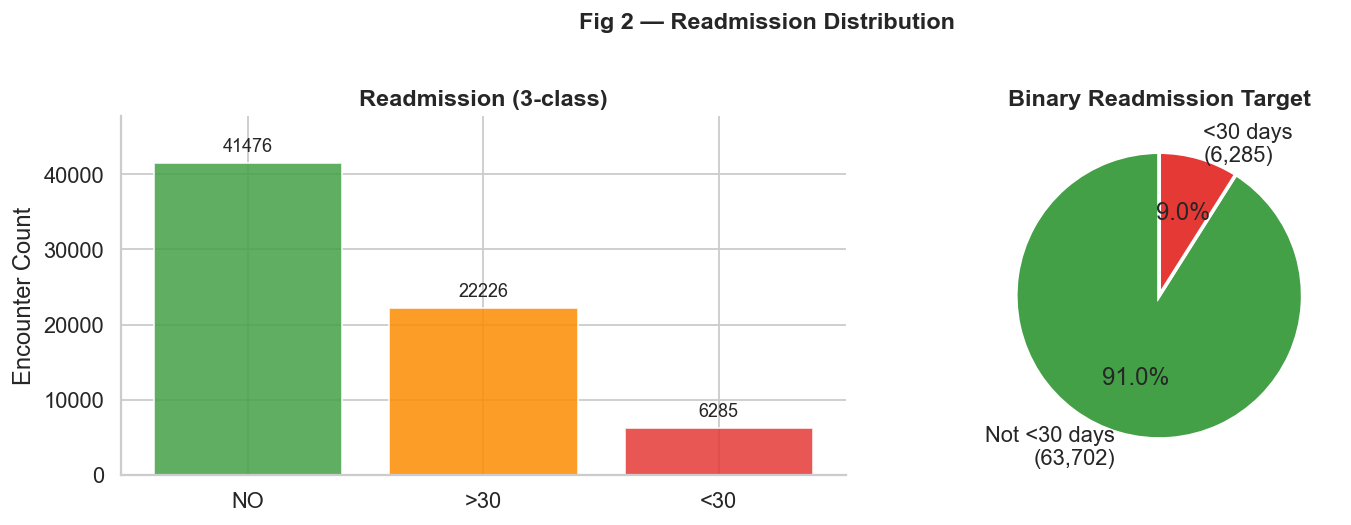

30-day readmission rate : 9.0%
Class imbalance         : 63,702 : 6,285  ≈  10:1


In [101]:
# ── Target variable distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 3-class bar
vc = df['readmitted'].value_counts().reindex(['NO', '>30', '<30'])
colors_3 = [GREEN, ORANGE, RED]
bars = axes[0].bar(vc.index, vc.values, color=colors_3, alpha=0.85, edgecolor='white')
axes[0].bar_label(bars, padding=4, fontsize=10)
axes[0].set_title('Readmission (3-class)')
axes[0].set_ylabel('Encounter Count')
axes[0].set_ylim(0, vc.max() * 1.15)

# Binary pie
vc2 = df['readmitted_binary'].value_counts().reindex([0, 1])
axes[1].pie(vc2.values,
            labels=[f'Not <30 days\n({vc2[0]:,})', f'<30 days\n({vc2[1]:,})'],
            colors=[GREEN, RED], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Binary Readmission Target')

plt.suptitle('Fig 2 — Readmission Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_02_target_distribution.png', bbox_inches='tight')
plt.show()

total = len(df)
print(f'30-day readmission rate : {df["readmitted_binary"].mean()*100:.1f}%')
print(f'Class imbalance         : {vc2[0]:,} : {vc2[1]:,}  ≈  {vc2[0]/vc2[1]:.0f}:1')

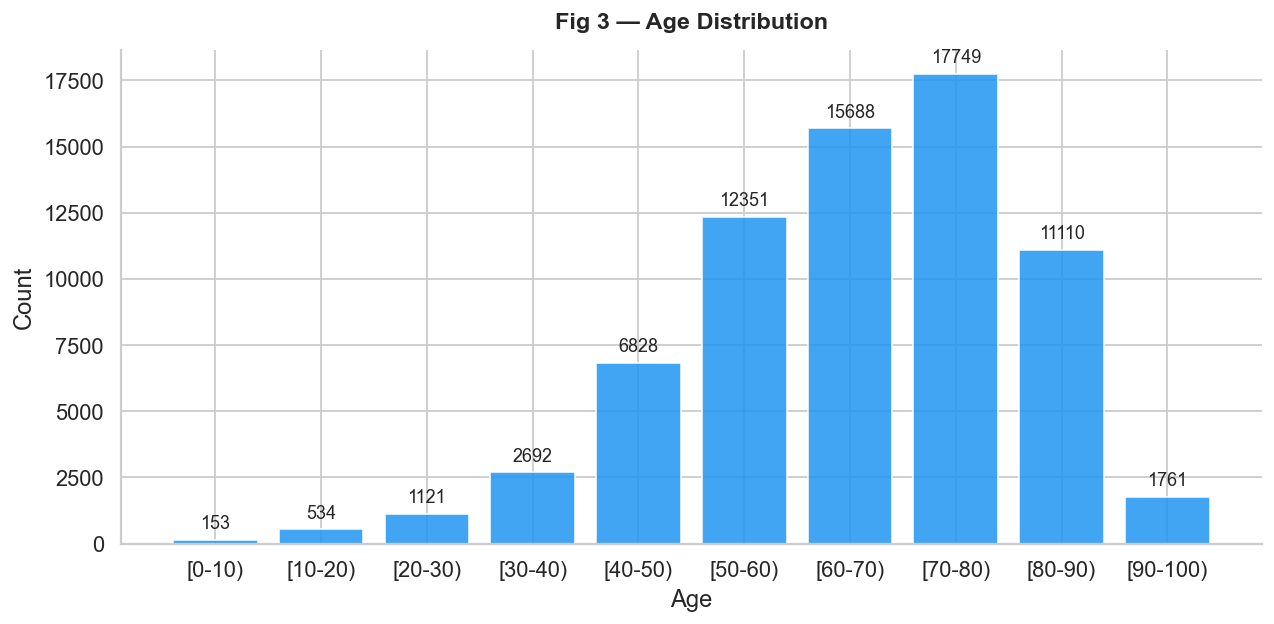

In [100]:
# Age distribution
age_order = list(age_map.keys())
age_vc = df['age'].value_counts().reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(age_vc.index, age_vc.values, color=BLUE, alpha=0.85, edgecolor='white')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title('Fig 3 — Age Distribution', fontsize=13, fontweight='bold', pad=12)
ax.bar_label(bars, padding=4, fontsize=10)
plt.tight_layout()
plt.show()


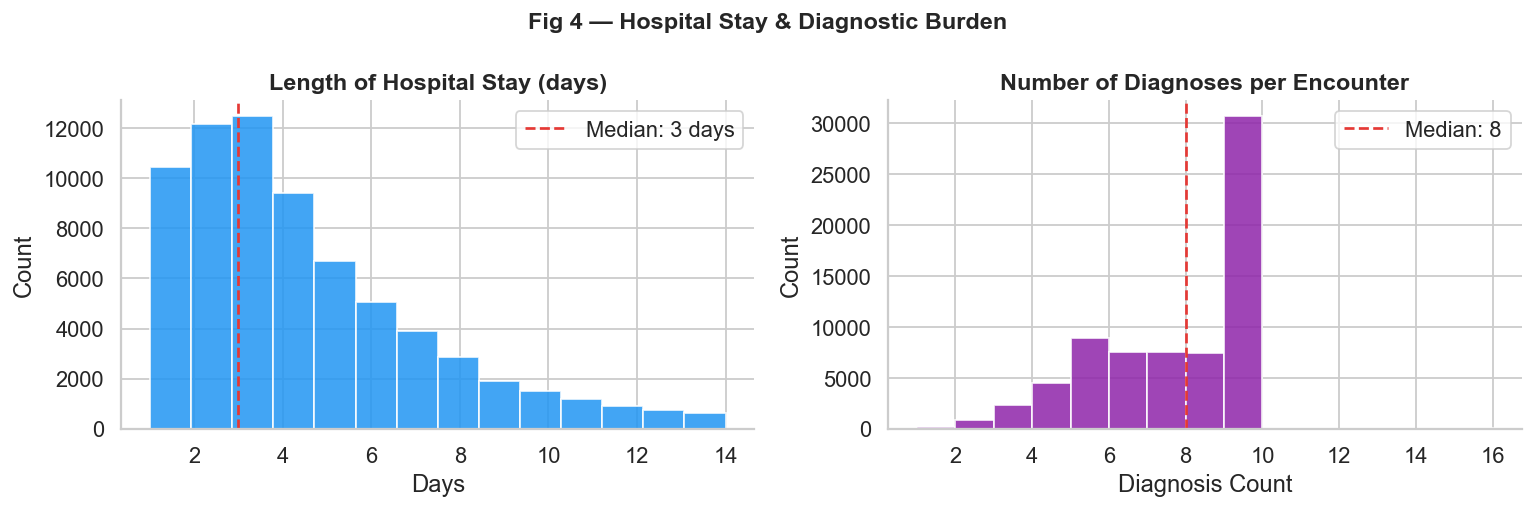

       time_in_hospital  number_diagnoses  number_inpatient  number_emergency  \
count          69987.00          69987.00          69987.00          69987.00   
mean               4.27              7.22              0.18              0.10   
std                2.93              2.00              0.60              0.51   
min                1.00              1.00              0.00              0.00   
25%                2.00              6.00              0.00              0.00   
50%                3.00              8.00              0.00              0.00   
75%                6.00              9.00              0.00              0.00   
max               14.00             16.00             12.00             42.00   

       number_outpatient  service_utilization  
count           69987.00             69987.00  
mean                0.28                 0.56  
std                 1.06                 1.43  
min                 0.00                 0.00  
25%                 0.00      

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['time_in_hospital'], bins=14,
             color=BLUE, edgecolor='white', alpha=0.85)
axes[0].set_title('Length of Hospital Stay (days)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Count')
axes[0].axvline(df['time_in_hospital'].median(), color=RED,
                linestyle='--', linewidth=1.5, label=f'Median: {df["time_in_hospital"].median():.0f} days')
axes[0].legend()

axes[1].hist(df['number_diagnoses'], bins=15,
             color=PURPLE, edgecolor='white', alpha=0.85)
axes[1].set_title('Number of Diagnoses per Encounter')
axes[1].set_xlabel('Diagnosis Count')
axes[1].set_ylabel('Count')
axes[1].axvline(df['number_diagnoses'].median(), color=RED,
                linestyle='--', linewidth=1.5,
                label=f'Median: {df["number_diagnoses"].median():.0f}')
axes[1].legend()

plt.suptitle('Fig 4 — Hospital Stay & Diagnostic Burden', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

stats_cols = ['time_in_hospital','number_diagnoses','number_inpatient',
              'number_emergency','number_outpatient','service_utilization']
print(df[stats_cols].describe().round(2))

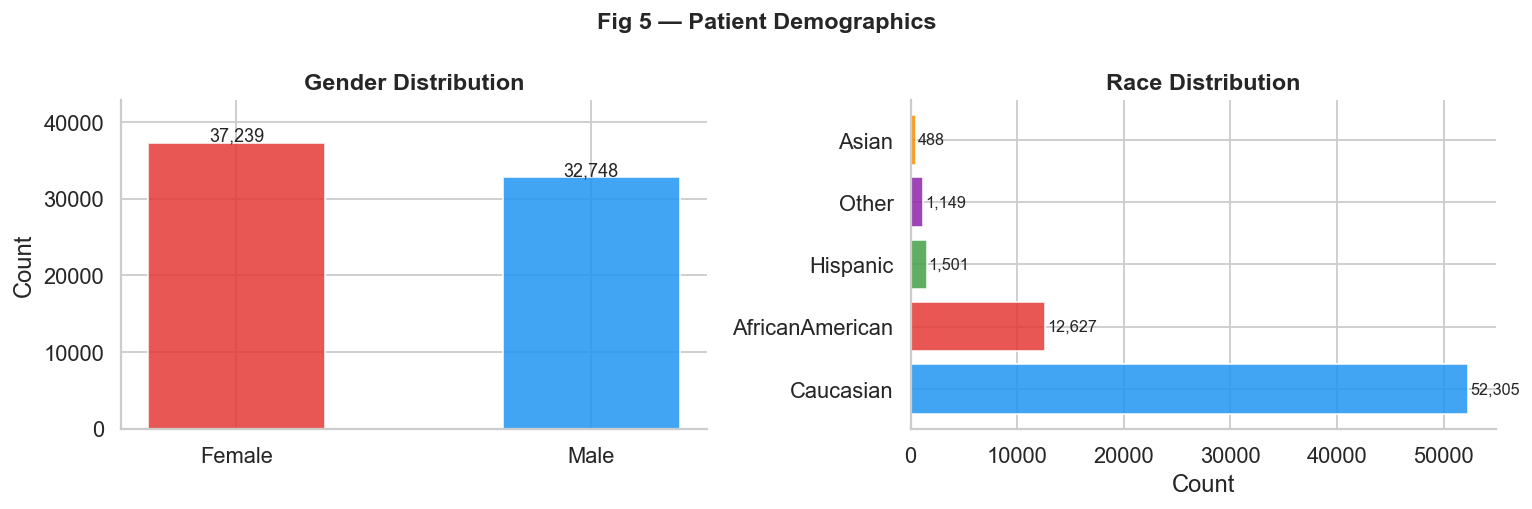

In [122]:
# ── Gender & race split ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gender
g_vc = df['gender'].value_counts()
axes[0].bar(g_vc.index, g_vc.values,
            color=[RED, BLUE], alpha=0.85, edgecolor='white', width=0.5)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 300,
                 f'{bar.get_height():,}', ha='center', fontsize=10)
axes[0].set_title('Gender Distribution')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, g_vc.max() * 1.15)

# Race (drop NaN for display)
r_vc = df['race'].value_counts().dropna()
axes[1].barh(r_vc.index, r_vc.values,
             color=PALETTE[:len(r_vc)], alpha=0.85, edgecolor='white')
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():,.0f}', va='center', fontsize=9)
axes[1].set_title('Race Distribution')
axes[1].set_xlabel('Count')

plt.suptitle('Fig 5 — Patient Demographics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_05_demographics.png', bbox_inches='tight')
plt.show()


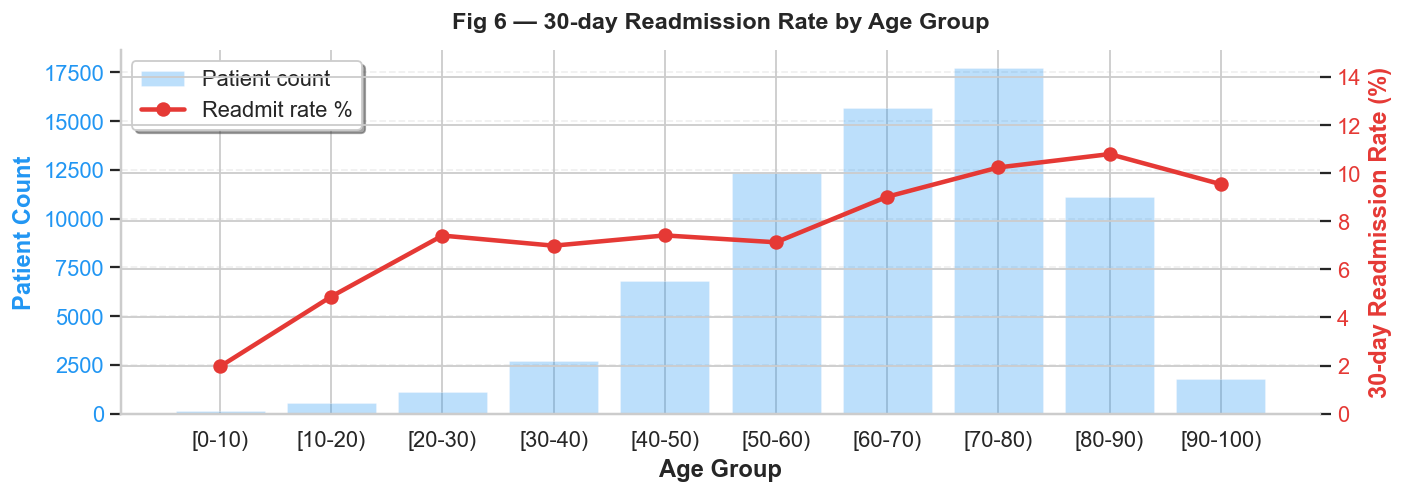

In [124]:
# ── Readmission rate by age group (dual-axis) ────────────────────────────
# Group by age and calculate readmission rate and patient count
readmit_age = (df.groupby('age')['readmitted_binary']
                 .agg(['mean','count'])
                 .reindex(age_order)
                 .reset_index())
readmit_age.columns = ['age','readmit_rate','count']

# Create figure with dual y-axes
fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

# Left axis: Bar chart for patient count
ax1.bar(readmit_age['age'], readmit_age['count'],
        color=BLUE, alpha=0.30, label='Patient count', edgecolor='white', linewidth=0.5)

# Right axis: Line chart for readmission rate
ax2.plot(readmit_age['age'], readmit_age['readmit_rate']*100,
         color=RED, marker='o', linewidth=2.5, markersize=7,
         label='Readmit rate %')

# Configure left axis (count)
ax1.set_xlabel('Age Group', fontweight='bold')
ax1.set_ylabel('Patient Count', color=BLUE, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=BLUE)

# Configure right axis (rate)
ax2.set_ylabel('30-day Readmission Rate (%)', color=RED, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=RED)
ax2.set_ylim(0, readmit_age['readmit_rate'].max()*100 * 1.4)

# Combine legends from both axes
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, l1+l2, loc='upper left', frameon=True, shadow=True)

# Add title and formatting
ax1.set_title('Fig 6 — 30-day Readmission Rate by Age Group', fontsize=13, fontweight='bold', pad=12)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_06_readmission_by_age.png', bbox_inches='tight', dpi=180)
plt.show()



In [ ]:
# ── Export clean CSV ──────────────────────────────────────────────────────
export_cols = [
    'age', 'age_mid', 'gender', 'race',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses',
    'diag_1', 'diag_2', 'diag_3',
    'A1Cresult', 'insulin', 'change', 'diabetesMed',
    'service_utilization', 'n_meds_active', 'age_midpoint', 'high_utilizer',
    'readmitted', 'readmitted_binary'
]
available = [c for c in export_cols if c in df.columns]
df_clean = df[available].copy()

df_clean.to_csv('diabetes_clean.csv', index=False)
print(f'Exported: diabetes_clean.csv')
print(f'  Rows   : {df_clean.shape[0]:,}')
print(f'  Columns: {df_clean.shape[1]}')
print(f'\nColumns in clean file:')
for c in df_clean.columns:
    print(f'  {c}')


Exported: diabetes_clean.csv
  Rows   : 69,987
  Columns: 26

Columns in clean file:
  age
  gender
  race
  admission_type_id
  discharge_disposition_id
  admission_source_id
  time_in_hospital
  num_lab_procedures
  num_procedures
  num_medications
  number_outpatient
  number_emergency
  number_inpatient
  number_diagnoses
  diag_1
  diag_2
  diag_3
  A1Cresult
  insulin
  change
  diabetesMed
  service_utilization
  n_meds_active
  high_utilizer
  readmitted
  readmitted_binary


In [128]:
import os

# Print the exact folder path where your file is saved
print("Current Directory:", os.getcwd())

# Check if your exported file is in this directory
file_name = "diabetes_clean.csv"  # Replace with your exact filename
if os.path.exists(file_name):
    print(f"\n✅ File found! Full path:\n{os.path.abspath(file_name)}")
else:
    print(f"\n❌ File '{file_name}' not found in current folder. Check the filename or check folder files below:")
    print(os.listdir())

Current Directory: c:\Users\Dilip\AppData\Local\Programs\Microsoft VS Code

✅ File found! Full path:
c:\Users\Dilip\AppData\Local\Programs\Microsoft VS Code\diabetes_clean.csv


In [126]:
# ── Final validation ──────────────────────────────────────────────────────
print('=== Final data quality check ===')
print(f'Remaining nulls:')
null_check = df_clean.isnull().sum()
print(null_check[null_check > 0].to_string() if null_check.any() else '  None ✓')

print(f'\nTarget distribution:')
print(df_clean['readmitted'].value_counts().to_string())

print(f'\nReadmission rate: {df_clean["readmitted_binary"].mean()*100:.2f}%')
print('\n✅ Phase 1 complete — diabetes_clean.csv ready for Phase 2 (SQL)')

=== Final data quality check ===
Remaining nulls:
race          1917
diag_1          10
diag_2         293
diag_3        1224
A1Cresult    57141

Target distribution:
readmitted
NO     41476
>30    22226
<30     6285

Readmission rate: 8.98%

✅ Phase 1 complete — diabetes_clean.csv ready for Phase 2 (SQL)


In [130]:
pip install google-cloud-bigquery pandas-gbq google-auth

     -------------------------------------- 267.7/267.7 kB 4.2 MB/s eta 0:00:00
     ---------------------------------------- 51.9/51.9 kB 1.3 MB/s eta 0:00:00
     -------------------------------------- 259.7/259.7 kB 1.1 MB/s eta 0:00:00
     ------------------------------------ 180.5/180.5 kB 990.1 kB/s eta 0:00:00
     ---------------------------------------- 81.5/81.5 kB 1.5 MB/s eta 0:00:00
     ---------------------------------------- 73.1/73.1 kB 2.0 MB/s eta 0:00:00
     -------------------------------------- 27.9/27.9 MB 999.0 kB/s eta 0:00:00
     -------------------------------------- 181.3/181.3 kB 1.2 MB/s eta 0:00:00
     ---------------------------------------- 3.8/3.8 MB 1.2 MB/s eta 0:00:00
     -------------------------------------- 185.1/185.1 kB 2.8 MB/s eta 0:00:00
     -------------------------------------- 307.0/307.0 kB 1.2 MB/s eta 0:00:00
     -------------------------------------- 456.5/456.5 kB 1.4 MB/s eta 0:00:00
     -------------------------------------

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\Dilip\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\pyasn1_modules\\rfc1902.py'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached google_cloud_bigquery-3.44.0-py3-none-any.whl (267 kB)
  Using cached pandas_gbq-0.35.2-py3-none-any.whl (51 kB)
  Using cached google_auth-2.57.0-py3-none-any.whl (259 kB)
  Using cached google_api_core-2.34.0-py3-none-any.whl (180 kB)
  Using cached google_cloud_core-2.7.0-py3-none-any.whl (31 kB)
  Using cached google_resumable_media-2.10.2-py3-none-any.whl (81 kB)
  Using cached requests-2.34.2-py3-none-any.whl (73 kB)
  Using cached db_dtypes-1.7.1-py3-none-any.whl (17 kB)
  Using cached pyarrow-25.0.1-cp311-cp311-win_amd64.whl (27.9 MB)
  Using cached pydata_google_auth-1.9.1-py2.py3-none-any.whl (15 kB)
  Using cached google_auth_oauthlib-1.4.1-py3-none-any.whl (19 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl (181 kB)
  Using cached cryptography-50.0.1-cp311-abi3-win_amd64.whl (3.8 MB)
  Using cached cffi-2.1.1-cp311-cp311-win_amd64.whl (185 kB)
  Using cached googleapis_common_protos-1.75.2-py3-none-any.whl (307 kB)
  Using cached protobuf-7.36.1-cp31


[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [135]:
import os
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas as pd

# ==========================================
# 1. CONFIGURATION & FILE VERIFICATION
# ==========================================
KEY_PATH = "gcp_key.json"
PROJECT_ID = "healthcare-507513"
DATASET_ID = "diabetes_data"
TABLE_NAME = "diabetes_clean"

# Verify key file presence in the VS Code working folder
if not os.path.exists(KEY_PATH):
    print("📍 Current Working Folder:", os.getcwd())
    raise FileNotFoundError(
        f"❌ 'gcp_key.json' was not found in this folder! Make sure it is inside your open VS Code folder."
    )

print("✅ Found 'gcp_key.json'!")

# ==========================================
# 2. LOAD YOUR CLEAN DATASET
# ==========================================
# Replace 'cleaned_diabetes.csv' with your actual CSV path/filename from Phase 1
DATA_PATH = "diabetes_clean.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"❌ Dataset file '{DATA_PATH}' not found. Update DATA_PATH with your exact CSV filename."
    )

print(f"📖 Reading dataset from {DATA_PATH}...")
df = pd.read_csv(DATA_PATH)
print(
    f"📊 Loaded DataFrame with {df.shape[0]} rows and {df.shape[1]} columns."
)

# ==========================================
# 3. AUTHENTICATE & STREAM TO BIGQUERY
# ==========================================
print("🔑 Authenticating with Google Cloud...")
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)
client = bigquery.Client(credentials=credentials, project=PROJECT_ID)

table_id = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}"
job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",  # Overwrites existing table
)

print(f"🚀 Uploading DataFrame directly to BigQuery: {table_id} ...")
job = client.load_table_from_dataframe(df, table_id, job_config=job_config)

# Wait for job completion
job.result()

print("=" * 60)
print(
    f"🎉 SUCCESS! Loaded {job.output_rows} rows into BigQuery table: {table_id}"
)
print("=" * 60)

✅ Found 'gcp_key.json'!
📖 Reading dataset from diabetes_clean.csv...
📊 Loaded DataFrame with 69987 rows and 26 columns.
🔑 Authenticating with Google Cloud...
🚀 Uploading DataFrame directly to BigQuery: healthcare-507513.diabetes_data.diabetes_clean ...
🎉 SUCCESS! Loaded 69987 rows into BigQuery table: healthcare-507513.diabetes_data.diabetes_clean


In [142]:
print(df['diabetes_clean'].head())

KeyError: 'diabetes_clean'